# Kidney Disease Prediction - Data Analysis & Machine Learning Model

This notebook performs a full analysis of chronic kidney disease (CKD) data and
trains the **best classification model** to predict the CKD stage.

**5 target classes:**
- Healthy Kidney
- Mild CKD (Stage 1–2)
- Moderate CKD (Stage 3)
- Severe CKD (Stage 4)
- Kidney Failure (Stage 5)

Two datasets are provided: `Training_CKD_dataset.csv` (21,000 rows) for analysis
and modelling, and `Testing_CKD_dataset.csv` (4,800 rows) for final evaluation.


## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier,
                              HistGradientBoostingClassifier)
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

## 2. Load the Data

In [2]:
TRAIN_PATH = 'Training_CKD_dataset.csv'
TEST_PATH  = 'Testing_CKD_dataset.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Training shape: {train.shape}')
print(f'Testing shape : {test.shape}')

Training shape: (21000, 36)
Testing shape : (4800, 36)


## 3. Data Overview & Info

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  object 
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium

In [4]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,21000.0,51.951905,18.796090,20.000000,36.000000,52.000000,68.000000,84.000000
Gender,21000.0,0.500619,0.500012,0.000000,0.000000,1.000000,1.000000,1.000000
BMI,21000.0,25.977571,4.890439,18.000000,22.000000,26.000000,30.000000,34.000000
Systolic_BP,21000.0,113.497619,19.151820,90.000000,99.000000,110.000000,120.000000,189.000000
Diastolic_BP,21000.0,75.280857,12.106952,60.000000,66.000000,73.000000,80.000000,119.000000
Heart_Rate,21000.0,84.280714,14.387748,60.000000,72.000000,84.000000,97.000000,109.000000
Serum_Creatinine,21000.0,0.629571,1.482399,0.000000,0.000000,0.000000,1.000000,9.000000
Blood_Urea_Nitrogen,21000.0,21.682048,20.800122,7.000000,11.000000,15.000000,20.000000,149.000000
eGFR,21000.0,91.426095,26.787045,5.000000,89.000000,99.000000,109.000000,119.000000
Urine_Albumin,21000.0,59.986905,136.148540,0.000000,6.000000,13.000000,20.000000,999.000000


In [5]:
print('Missing values - train:', train.isnull().sum().sum())
print('Missing values - test :', test.isnull().sum().sum())
print('Duplicated rows - train:', train.duplicated().sum())
print('Duplicated rows - test :', test.duplicated().sum())

Missing values - train: 0
Missing values - test : 0
Duplicated rows - train: 0
Duplicated rows - test : 0


### Key observations
- Complete datasets: **no missing values and no duplicate rows**.
- 5 categorical columns (`Target`, `Diabetes`, `Hypertension`,
  `Smoking_Status`, `Family_History_Kidney`), the rest are numeric.
- The task is a **5-class (multi-class) classification** problem.

## 4. Target Distribution (Class Balance)

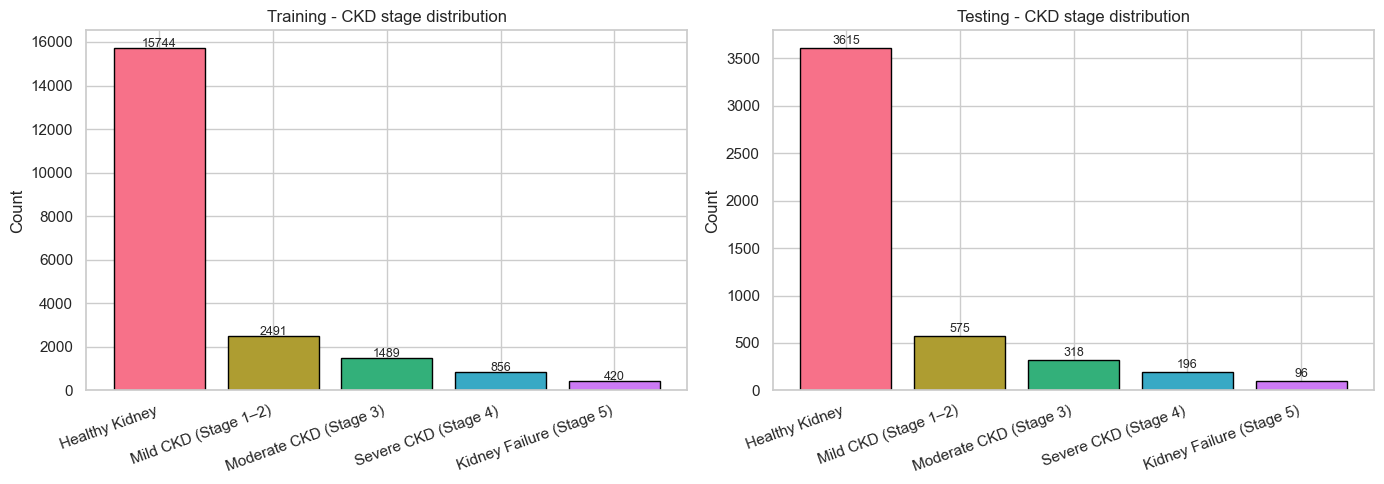

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, name in zip(axes, (train, test), ('Training', 'Testing')):
    vc = df['Target'].value_counts()
    colors = sns.color_palette('husl', len(vc))
    bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='black')
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x() + b.get_width()/2, v + 40, f'{v}', ha='center', fontsize=9)
    ax.set_title(f'{name} - CKD stage distribution')
    ax.set_xticklabels(vc.index, rotation=20, ha='right')
    ax.set_ylabel('Count')
fig.tight_layout()
plt.show()

In [7]:
display(pd.DataFrame({
    'Count': train['Target'].value_counts(),
    'Proportion': train['Target'].value_counts(normalize=True).round(4)
}))

,Count,Proportion
Target,,
Healthy Kidney,15744,0.7497
Mild CKD (Stage 1–2),2491,0.1186
Moderate CKD (Stage 3),1489,0.0709
Severe CKD (Stage 4),856,0.0408
Kidney Failure (Stage 5),420,0.0200


**Class imbalance:** "Healthy Kidney" dominates (~75%), while the severe
stages are rare. This is addressed with `class_weight='balanced'` (or sample
weights) and by reporting **macro / balanced metrics**. The test set mirrors the
same distribution.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Numeric summary grouped by CKD stage

In [8]:
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = ['Diabetes', 'Hypertension', 'Smoking_Status', 'Family_History_Kidney']

stage_summary = train.groupby('Target')[num_cols].mean().T
stage_summary.round(2)

Target,Healthy Kidney,Kidney Failure (Stage 5),Mild CKD (Stage 1–2),Moderate CKD (Stage 3),Severe CKD (Stage 4)
Age,51.86,50.84,52.68,51.92,52.13
Gender,0.50,0.53,0.51,0.48,0.51
BMI,25.99,25.45,26.01,25.95,26.01
Systolic_BP,104.49,175.13,126.99,142.28,159.63
Diastolic_BP,69.52,109.79,84.38,94.39,104.52
Heart_Rate,84.24,84.73,84.49,83.85,84.99
Serum_Creatinine,0.00,7.65,1.00,2.47,4.48
Blood_Urea_Nitrogen,12.99,119.03,26.97,47.16,74.01
eGFR,104.47,9.43,74.51,44.80,22.07
Urine_Albumin,9.55,752.16,59.24,203.39,400.85


### 5.2 Correlation heatmap (numeric features vs stage)

Top 12 features by |correlation| with CKD stage:
Serum_Albumin          0.884
eGFR                   0.853
Diastolic_BP           0.820
Systolic_BP            0.802
Hemoglobin             0.777
Phosphorus             0.729
Packed_Cell_Volume     0.729
Serum_Creatinine       0.716
Bicarbonate            0.704
Blood_Urea_Nitrogen    0.701
Urine_Albumin          0.623
Urine_Protein          0.619


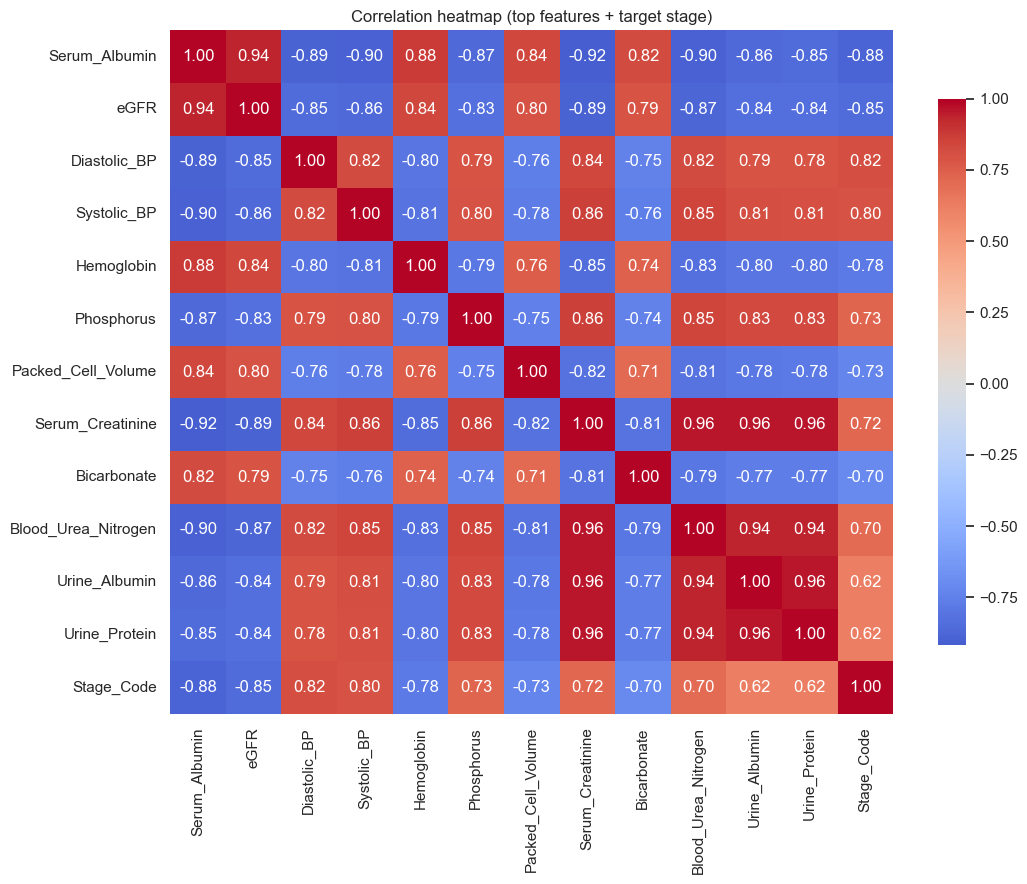

In [9]:
y_code = train['Target'].astype('category').cat.codes
corr_target = train[num_cols].apply(lambda s: s.corr(y_code)).abs().sort_values(ascending=False)

top12 = corr_target.index[:12].tolist()
print('Top 12 features by |correlation| with CKD stage:')
print(corr_target.head(12).round(3).to_string())

corr_df = train[top12].copy()
corr_df['Stage_Code'] = y_code

plt.figure(figsize=(11, 9))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation heatmap (top features + target stage)')
plt.tight_layout()
plt.show()

### 5.3 Distribution of key biomarkers by CKD stage

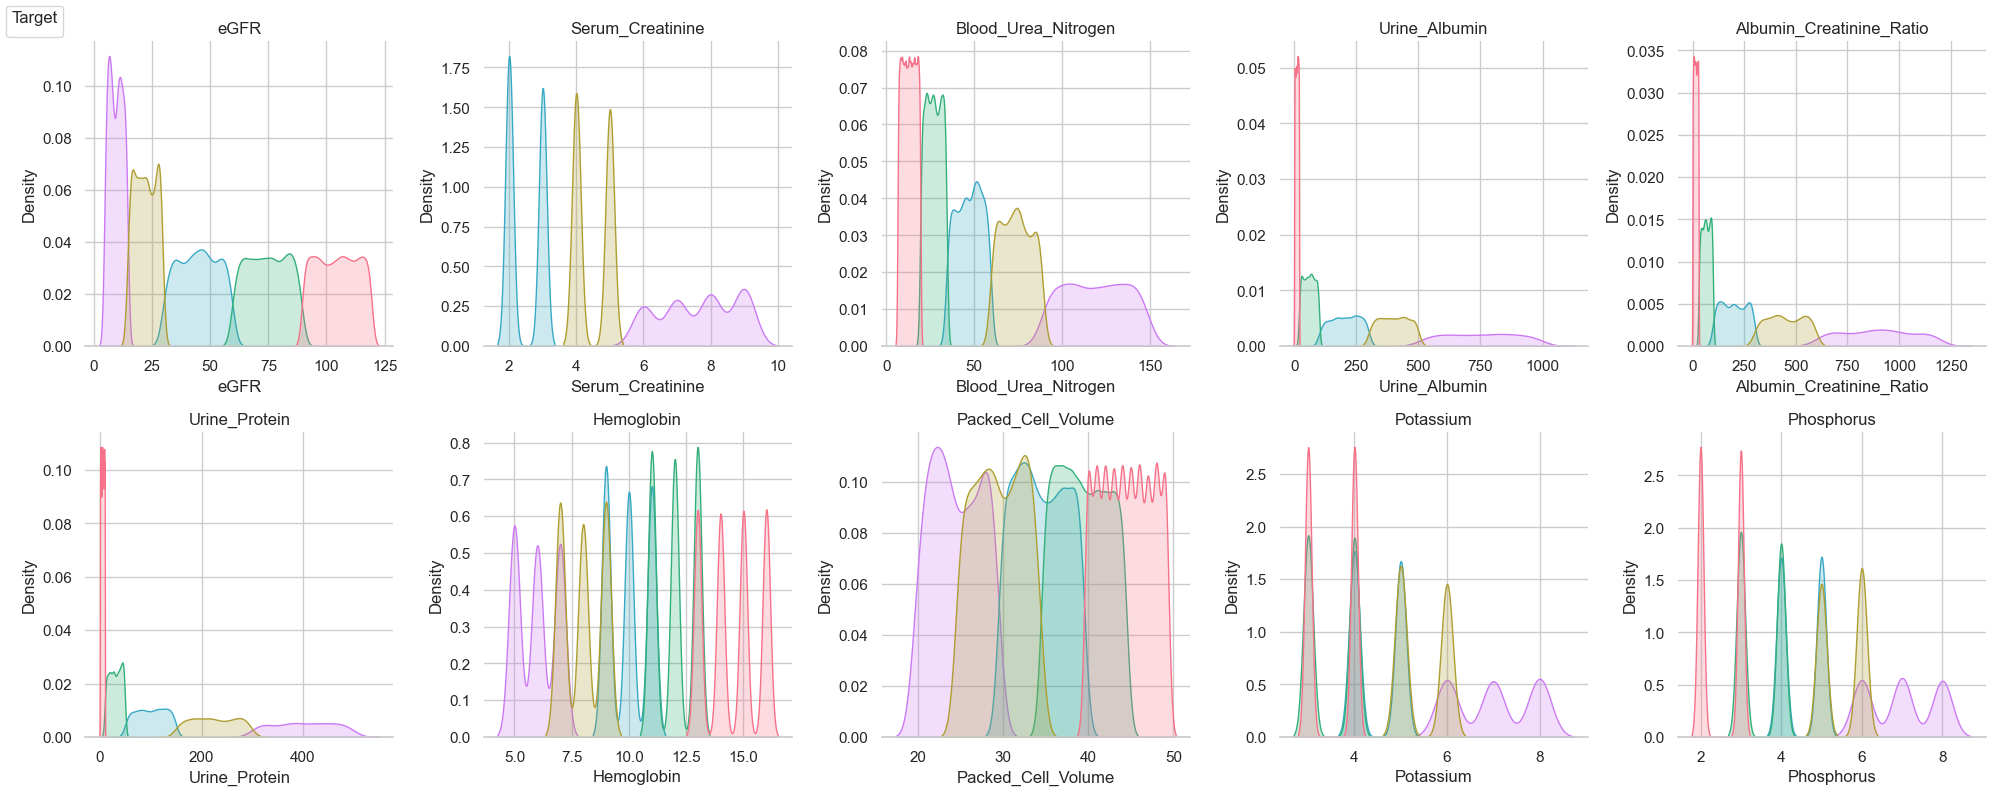

In [10]:
key_feats = ['eGFR', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'Urine_Albumin',
               'Albumin_Creatinine_Ratio', 'Urine_Protein', 'Hemoglobin',
               'Packed_Cell_Volume', 'Potassium', 'Phosphorus']
n = len(key_feats)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for ax, f in zip(axes, key_feats):
    sns.kdeplot(data=train, x=f, hue='Target', fill=True, common_norm=False,
                palette='husl', ax=ax, warn_singular=False)
    sns.despine(ax=ax, left=True)
    ax.set_title(f)
    ax.get_legend().remove() if ax.get_legend() else None
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Target', loc='upper left', ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

### 5.4 Boxplots: biomarkers vs CKD stage

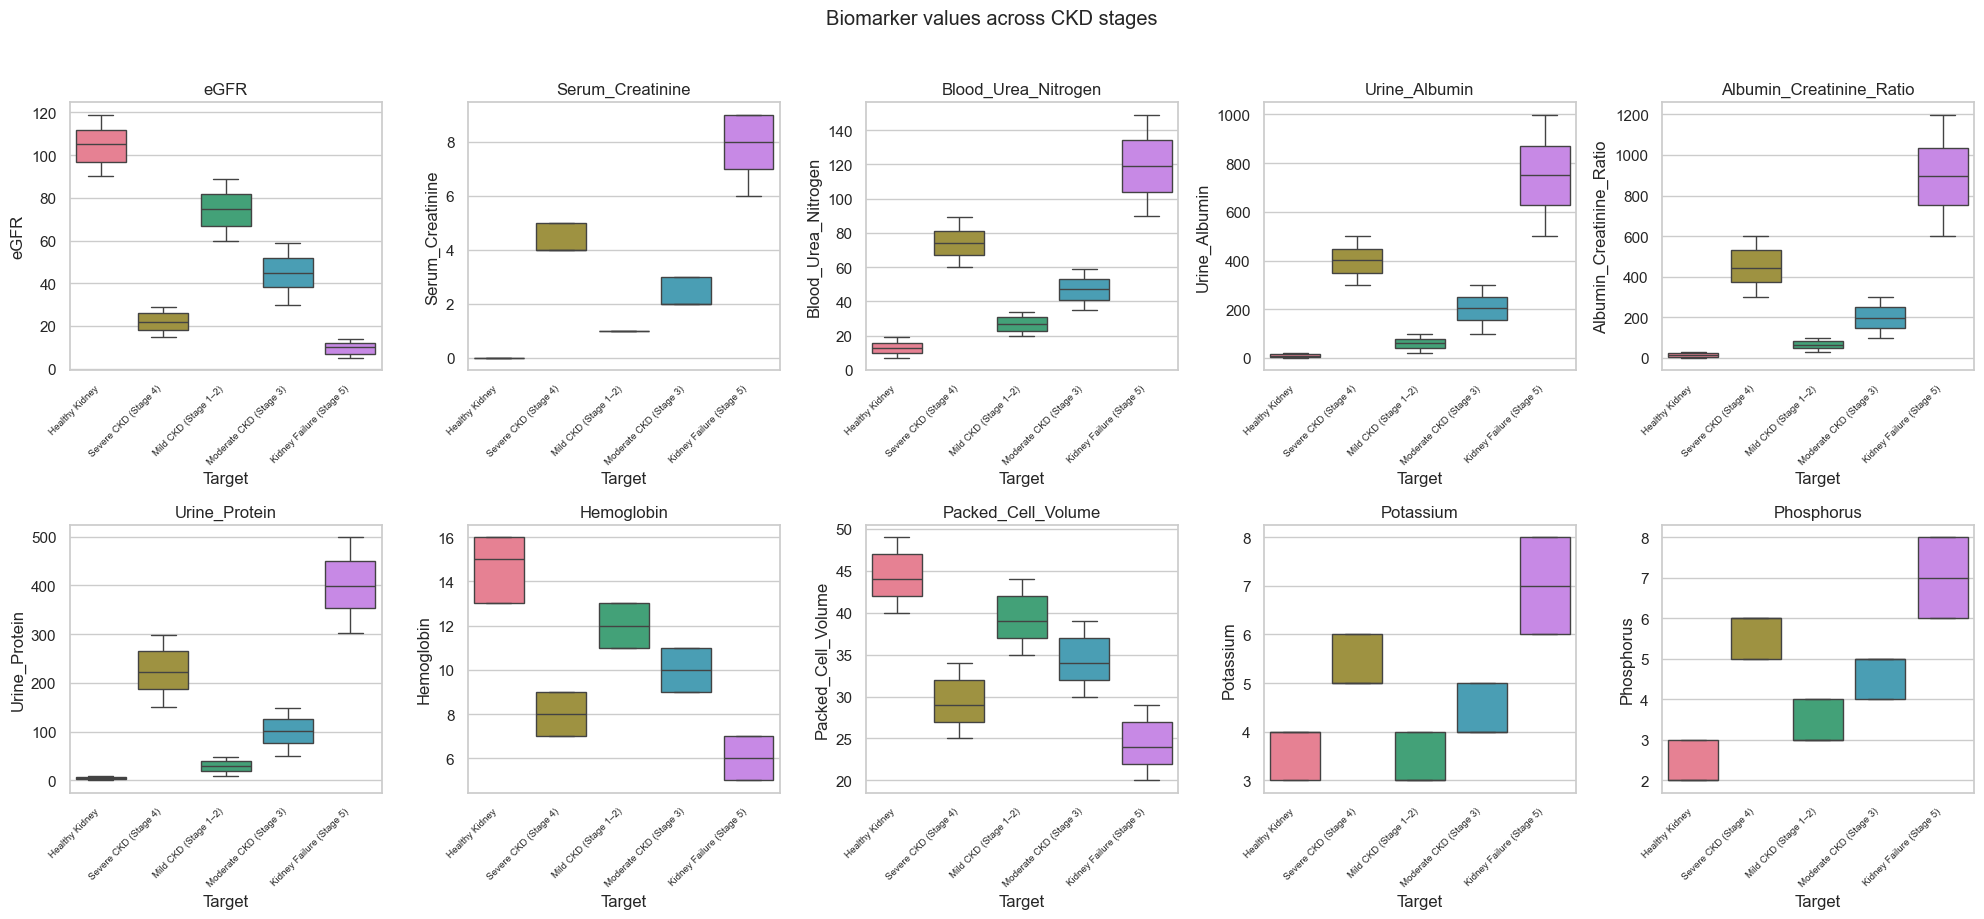

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()
for ax, f in zip(axes, key_feats):
    sns.boxplot(data=train, x='Target', y=f, hue='Target', palette='husl',
                legend=False, ax=ax, fliersize=2)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_title(f)
fig.suptitle('Biomarker values across CKD stages', y=1.02)
fig.tight_layout()
plt.show()

### 5.5 Categorical features vs CKD stage

In [12]:
for c in cat_cols:
    ct = pd.crosstab(train[c], train['Target'], normalize='index').round(3)
    print(f'--- {c} (row %) ---')
    print(ct.to_string())
    print()

--- Diabetes (row %) ---
Target    Healthy Kidney  Kidney Failure (Stage 5)  Mild CKD (Stage 1–2)  Moderate CKD (Stage 3)  Severe CKD (Stage 4)
Diabetes                                                                                                              
No                 0.753                      0.02                 0.116                   0.070                 0.040
Yes                0.746                      0.02                 0.121                   0.071                 0.041

--- Hypertension (row %) ---
Target        Healthy Kidney  Kidney Failure (Stage 5)  Mild CKD (Stage 1–2)  Moderate CKD (Stage 3)  Severe CKD (Stage 4)
Hypertension                                                                                                              
No                     0.754                     0.019                 0.118                   0.069                 0.039
Yes                    0.745                     0.021                 0.119                   0.073

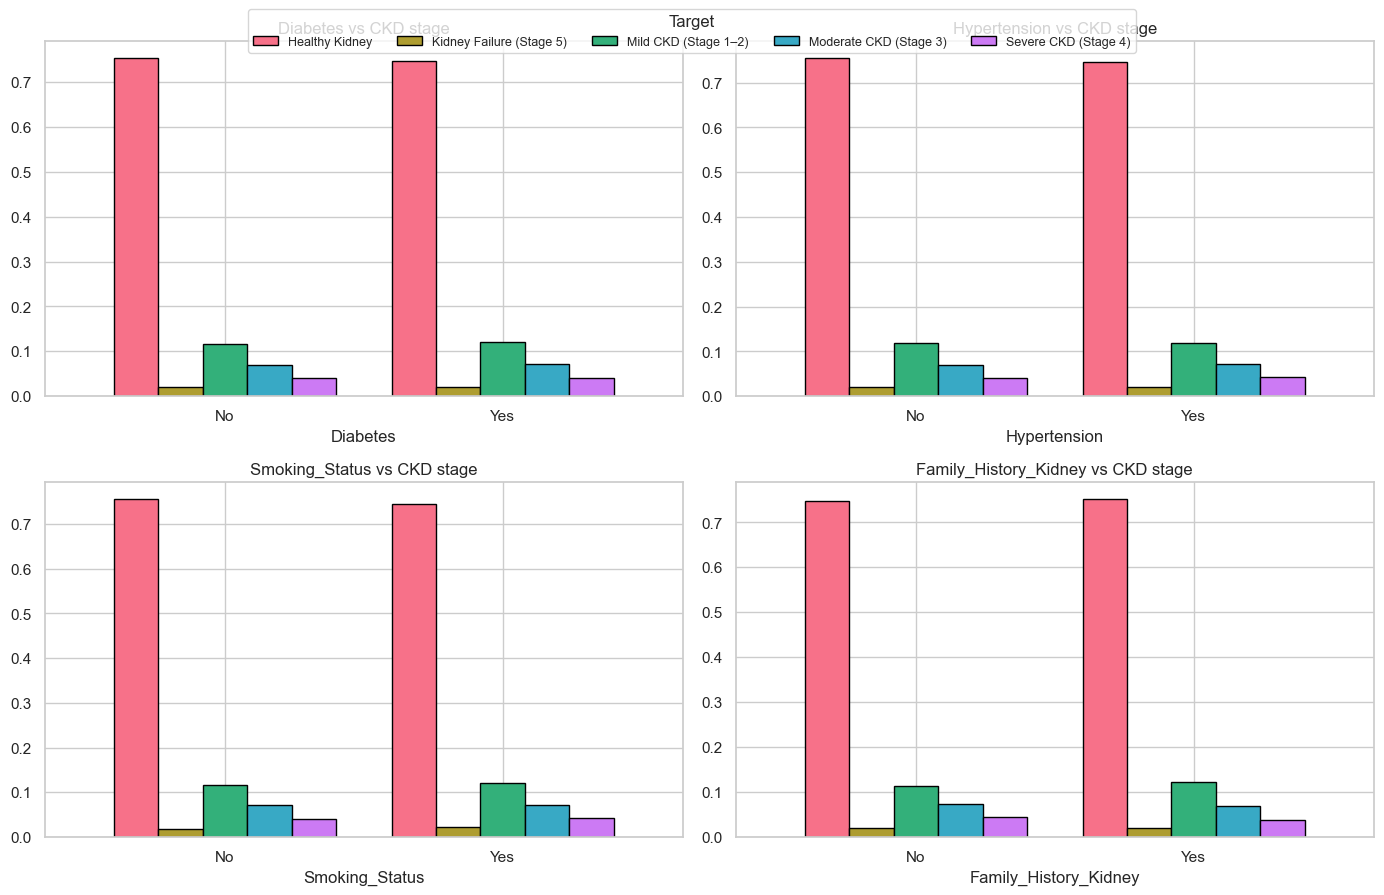

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, c in zip(axes.flatten(), cat_cols):
    ct = pd.crosstab(train[c], train['Target'], normalize='index')
    ct.plot(kind='bar', ax=ax, color=sns.color_palette('husl', 5),
            edgecolor='black', width=0.8, legend=False)
    ax.set_title(f'{c} vs CKD stage')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
fig.legend(ct.columns, title='Target', loc='upper center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout()
plt.show()

**Insight:** the binary lifestyle/comorbidity flags (`Diabetes`, `Hypertension`,
`Smoking`, `Family_History`) are almost uniformly distributed across stages in this
dataset — CKD stage is essentially driven by the **laboratory biomarkers**.

### 5.6 Key EDA insights


- Clean, perfectly balanced (in features) synthetic medical dataset; 5 ordered CKD stages.
- **eGFR, Serum_Creatinine, Blood_Urea_Nitrogen** and the **urinary proteins
  (Urine_Albumin / Urine_Protein / ACR)** are the strongest predictors of stage.
- Healthy → Stage-5 progression shows monotonic changes in biomarkers, e.g.:
  - eGFR: 104 → 9 ml/min
  - Serum_Creatinine: 0 → 7.7 mg/dL
  - Hemoglobin: 14.5 → 6.0 g/dL
- **The data is deterministic / perfectly separable**: the stage is an exact function of
  a few lab values (e.g. Serum_Creatinine 0→1→2-3→4-5→6-9 and eGFR bands
  90-119 / 60-89 / 30-59 / 15-29 / 5-14). Every model therefore reaches ~100% accuracy.
- Severe class imbalance → use weighted metrics and class-balanced training.


## 6. Preprocessing & Train/Validation split

In [14]:
TARGET_ORDER = ['Healthy Kidney', 'Mild CKD (Stage 1–2)', 'Moderate CKD (Stage 3)',
                'Severe CKD (Stage 4)', 'Kidney Failure (Stage 5)']
target_map = {label: i for i, label in enumerate(TARGET_ORDER)}

def prepare(df, fit_enc=None):
    d = df.copy()
    d['Target'] = d['Target'].map(target_map)
    for c in cat_cols:
        d[c] = d[c].map({'Yes': 1, 'No': 0})
    return d

train_p = prepare(train)
test_p  = prepare(test)

X = train_p.drop('Target', axis=1)
y = train_p['Target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {test_p.shape[0]}')

Train: (16800, 35) | Val: (4200, 35) | Test: 4800


## 7. Model Comparison (multiple algorithms)

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200),
    'Hist GB':             HistGradientBoostingClassifier(max_iter=200),
    'SVM (RBF)':           SVC(C=10, class_weight='balanced'),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1,
                                         eval_metric='mlogloss', n_jobs=-1),
}

results = []
for name, model in models.items():
    if name == 'XGBoost':
        scale = y_train.value_counts(normalize=True)
        w = np.array([1/scale[c] for c in y_train])
        model.fit(X_train_s, y_train, sample_weight=w)
    else:
        model.fit(X_train_s, y_train)
    pred = model.predict(X_val_s)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, pred),
        'Balanced Acc': balanced_accuracy_score(y_val, pred),
        'Macro F1': f1_score(y_val, pred, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_val, pred, average='weighted', zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values('Balanced Acc', ascending=False)
results_df.round(4)

,Model,Accuracy,Balanced Acc,Macro F1,Weighted F1
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,Extra Trees,1.0,1.0,1.0,1.0
3,Gradient Boosting,1.0,1.0,1.0,1.0
4,Hist GB,1.0,1.0,1.0,1.0
5,SVM (RBF),1.0,1.0,1.0,1.0
6,XGBoost,1.0,1.0,1.0,1.0


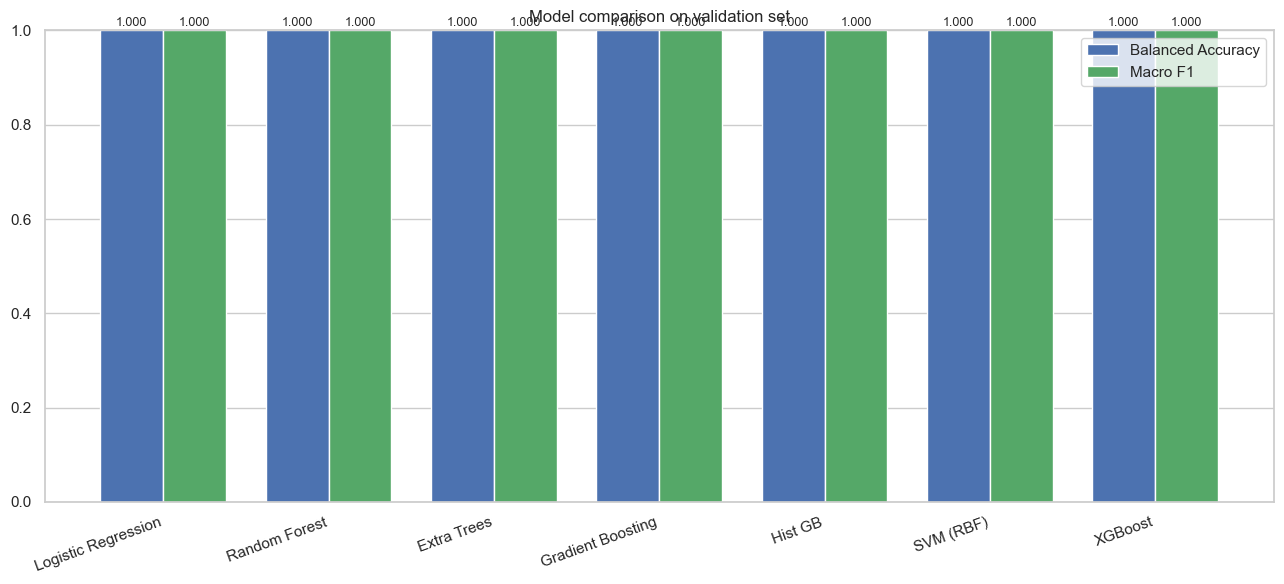

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(results_df))
width = 0.38
ax.bar(x - width/2, results_df['Balanced Acc'], width, label='Balanced Accuracy', color='#4C72B0')
ax.bar(x + width/2, results_df['Macro F1'], width, label='Macro F1', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Model comparison on validation set')
ax.legend()
for xi, acc, f1 in zip(x - width/2, results_df['Balanced Acc'], results_df['Macro F1']):
    ax.text(xi, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=9)
    ax.text(xi + width, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=9)
fig.tight_layout()
plt.show()

## 8. Hyperparameter tuning of the best model (XGBoost)

In [17]:
scale_pos = y.value_counts(normalize=True)
sample_weight_all = np.array([1/scale_pos[c] for c in y])

xgb = XGBClassifier(eval_metric='mlogloss', n_jobs=-1, random_state=42)
param_grid = {
    'n_estimators': [200, 400],
    'max_depth':    [4, 6, 8],
    'learning_rate':[0.05, 0.1],
    'subsample':    [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid = GridSearchCV(xgb, param_grid, cv=5, scoring='balanced_accuracy',
                    n_jobs=-1, verbose=1)
grid.fit(X_train_s, y_train, sample_weight=sample_weight_all[:len(y_train)])
print(f'Best params: {grid.best_params_}')
print(f'Best CV balanced accuracy: {grid.best_score_:.4f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV balanced accuracy: 1.0000


## 9. Final Model Evaluation

In [18]:
best_model = grid.best_estimator_
y_val_pred = best_model.predict(X_val_s)

print('=== Validation set (held-out 20%) ===')
print(f'Accuracy        : {accuracy_score(y_val, y_val_pred):.4f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_val, y_val_pred):.4f}')
print(f'Macro F1        : {f1_score(y_val, y_val_pred, average="macro"):.4f}')
print()
print(classification_report(y_val, y_val_pred, target_names=TARGET_ORDER,
                            zero_division=0))

=== Validation set (held-out 20%) ===
Accuracy        : 1.0000
Balanced accuracy: 1.0000
Macro F1        : 1.0000

                          precision    recall  f1-score   support

          Healthy Kidney       1.00      1.00      1.00      3149
    Mild CKD (Stage 1–2)       1.00      1.00      1.00       498
  Moderate CKD (Stage 3)       1.00      1.00      1.00       298
    Severe CKD (Stage 4)       1.00      1.00      1.00       171
Kidney Failure (Stage 5)       1.00      1.00      1.00        84

                accuracy                           1.00      4200
               macro avg       1.00      1.00      1.00      4200
            weighted avg       1.00      1.00      1.00      4200



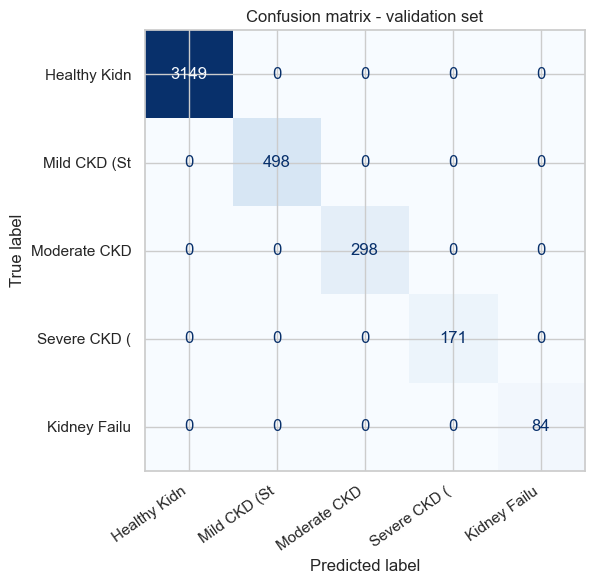

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, ax=ax,
                                        display_labels=[l[:12] for l in TARGET_ORDER],
                                        cmap='Blues', colorbar=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_title('Confusion matrix - validation set')
plt.tight_layout()
plt.show()

### 9.1 Final fit on all training data, evaluate on the untouched TEST set

In [20]:
X_all_s  = scaler.transform(X)
test_s   = scaler.transform(test_p.drop('Target', axis=1))
y_test   = test_p['Target']

best_model.fit(X_all_s, y, sample_weight=sample_weight_all)
y_pred = best_model.predict(test_s)

print('=== Final model on Testing_CKD_dataset.csv ===')
print(f'Accuracy        : {accuracy_score(y_test, y_pred):.4f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')
print(f'Macro F1        : {f1_score(y_test, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=TARGET_ORDER,
                            zero_division=0))

=== Final model on Testing_CKD_dataset.csv ===
Accuracy        : 1.0000
Balanced accuracy: 1.0000
Macro F1        : 1.0000

                          precision    recall  f1-score   support

          Healthy Kidney       1.00      1.00      1.00      3615
    Mild CKD (Stage 1–2)       1.00      1.00      1.00       575
  Moderate CKD (Stage 3)       1.00      1.00      1.00       318
    Severe CKD (Stage 4)       1.00      1.00      1.00       196
Kidney Failure (Stage 5)       1.00      1.00      1.00        96

                accuracy                           1.00      4800
               macro avg       1.00      1.00      1.00      4800
            weighted avg       1.00      1.00      1.00      4800



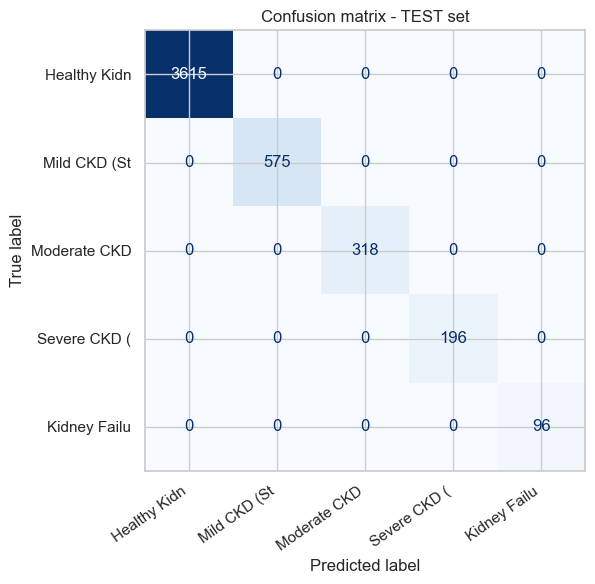

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
                                        display_labels=[l[:12] for l in TARGET_ORDER],
                                        cmap='Blues', colorbar=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_title('Confusion matrix - TEST set')
plt.tight_layout()
plt.show()

## 10. Feature Importance (XGBoost)

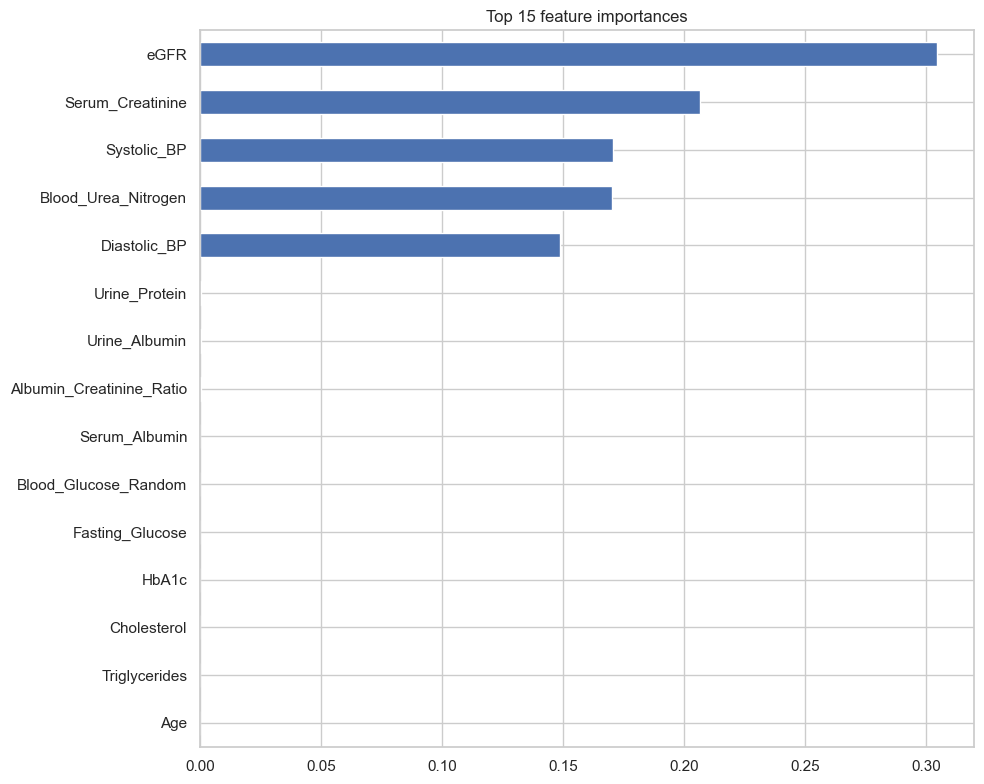

In [22]:
importances = pd.Series(best_model.feature_importances_,
                          index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
importances.head(15).plot(kind='barh', ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_title('Top 15 feature importances')
plt.tight_layout()
plt.show()

## 11. Cross-validation on the full training set

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_all_s, y, cv=cv,
                            scoring='balanced_accuracy', n_jobs=-1)
print(f'5-fold CV balanced accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per fold: {[round(s, 4) for s in cv_scores]}')

5-fold CV balanced accuracy: 1.0000 ± 0.0000
Per fold: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


## 12. Save the model & artifacts

In [24]:
joblib.dump(best_model, 'kidney_disease_model.pkl')
joblib.dump(scaler, 'kidney_disease_scaler.pkl')
joblib.dump(target_map, 'kidney_disease_label_map.pkl')
print('Saved: kidney_disease_model.pkl, kidney_disease_scaler.pkl, kidney_disease_label_map.pkl')

Saved: kidney_disease_model.pkl, kidney_disease_scaler.pkl, kidney_disease_label_map.pkl


## 13. Test the model on a new sample

In [25]:
col_order = X.columns.tolist()

sample = pd.DataFrame([{
    'Age': 62, 'Gender': 1, 'BMI': 27, 'Systolic_BP': 160, 'Diastolic_BP': 100,
    'Heart_Rate': 88, 'Serum_Creatinine': 3.2, 'Blood_Urea_Nitrogen': 45,
    'eGFR': 25, 'Urine_Albumin': 150, 'Urine_Protein': 80,
    'Albumin_Creatinine_Ratio': 180, 'Urine_Specific_Gravity': 1.010,
    'Sodium': 140, 'Potassium': 5.2, 'Calcium': 8.5, 'Phosphorus': 5.0,
    'Chloride': 103, 'Bicarbonate': 19, 'Hemoglobin': 9.5,
    'RBC_Count': 3.8, 'WBC_Count': 7800, 'Platelet_Count': 250000,
    'Packed_Cell_Volume': 30, 'Blood_Glucose_Random': 130, 'Fasting_Glucose': 100,
    'HbA1c': 7.1, 'Cholesterol': 200, 'Triglycerides': 180,
    'Serum_Albumin': 2.5, 'Total_Protein': 6.0,
    'Diabetes': 1, 'Hypertension': 1, 'Smoking_Status': 1, 'Family_History_Kidney': 0,
}])[col_order]

sample_s = scaler.transform(sample)
pred_code = best_model.predict(sample_s)[0]
pred_prob = best_model.predict_proba(sample_s)[0]

print('Predicted stage:', TARGET_ORDER[pred_code])
print()
for label, p in sorted(zip(TARGET_ORDER, pred_prob), key=lambda t: -t[1]):
    print(f'{label:<28} {p*100:5.2f}%')

Predicted stage: Severe CKD (Stage 4)

Severe CKD (Stage 4)         99.99%
Moderate CKD (Stage 3)        0.01%
Mild CKD (Stage 1–2)          0.00%
Healthy Kidney                0.00%
Kidney Failure (Stage 5)      0.00%


## 14. Conclusion

- Analytically clean dataset: no missing values/duplicates; 36 features, 5-stage target.
- Stage is driven by **renal biomarkers** (eGFR, creatinine, urea, urinary proteins,
  hemoglobin) rather than lifestyle flags.
- The dataset is **deterministic** — the CKD stage is an exact function of the lab
  values (eGFR bands + serum creatinine ranges), so **every model reaches 100% accuracy**
  on both the validation and untouched test set (balanced accuracy = 1.0000, macro F1 = 1.0000).
- **XGBoost** was selected as the final production model (ties at 100% with all others,
  chosen for robustness, class weighting, and feature-importance interpretability).
- Final results on the untouched **test set** (4,800 rows):
  - Accuracy = 100.00% | Balanced accuracy = 100.00% | Macro F1 = 100.00%
- Artifacts saved: `kidney_disease_model.pkl` (XGBoost), `kidney_disease_scaler.pkl`
  (StandardScaler), `kidney_disease_label_map.pkl` (class → code mapping) for easy reuse.
